# 02 – Mô hình phân loại nhóm chi phí

**Mục tiêu:** dự đoán nhóm chi phí (14 nhóm, xem `data/mcc_groups.csv`) cho từng giao dịch. Có hai tình huống sử dụng:
1. **Giao dịch thông thường:** có tên cửa hàng và mô tả mặt hàng.
2. **Giao dịch Amazon / cửa hàng bán đủ loại:** tên cửa hàng không cho biết gì, chỉ dựa được vào **mô tả mặt hàng**.

**Thiết kế thực nghiệm**
- Nhãn: nhóm chi phí suy từ MCC. Loại bỏ nhóm "Chưa xác định" (Amazon BOOK STORES, siêu thị…), nhóm "Khác" và giao dịch âm (hoàn tiền).
- Chia theo thời gian: huấn luyện 07/2025–03/2026, kiểm định 04–05/2026, **kiểm tra 06–08/2026**.
- So sánh 5 mô hình:

| Mô hình | Đầu vào | Dùng cho |
|---|---|---|
| A. Tra cứu | Nhóm phổ biến nhất của cửa hàng trong tập huấn luyện | Mốc so sánh |
| B. Văn bản | TF-IDF ký tự trên "mô tả + tên cửa hàng" → Logistic Regression | |
| B+. Văn bản + ngữ cảnh | B + đơn vị + số tiền | **Giao dịch thông thường** |
| C+. Mô tả + ngữ cảnh | TF-IDF trên **chỉ mô tả mặt hàng** + đơn vị + số tiền | |
| C++. Mô tả đã làm sạch + ngữ cảnh | Như C+ nhưng bỏ đuôi đơn vị tính (PCE, EA…) và tách các món trong đơn (mục 6) | **Amazon / cửa hàng bán đủ loại** |

In [1]:
import sys, time
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from src.data_loader import load_pcard
from src.labels import add_expense_group, GROUPS
from src.features import prepare, split, make_model, input_columns

pd.set_option('display.width', 160); pd.set_option('display.max_colwidth', 60)
BLUE, ORANGE, INK, INK2, GRID = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'font.family': ['Arial', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': INK2, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'figure.dpi': 110, 'figure.facecolor': 'white',
})

## 1. Dữ liệu

In [2]:
df = prepare(add_expense_group(load_pcard()))
data = df[df.label.notna() & (df.amount > 0)]
train, valid, test = split(data)
print(f'Có nhãn: {len(data):,} | Huấn luyện: {len(train):,} | Kiểm định: {len(valid):,} | Kiểm tra: {len(test):,}')

dist = pd.DataFrame({'Tên nhóm': [GROUPS[g] for g in train.label.value_counts().index],
                     'Huấn luyện': train.label.value_counts().values})
dist['Kiểm tra'] = test.label.value_counts().reindex(train.label.value_counts().index).values
dist.index = train.label.value_counts().index
dist

Có nhãn: 346,304 | Huấn luyện: 219,421 | Kiểm định: 52,976 | Kiểm tra: 73,907


,Tên nhóm,Huấn luyện,Kiểm tra
label,,,
FACILITIES_MRO,"Vật tư, xây dựng, sửa chữa & nội thất",41988,15018
LODGING,Lưu trú khách sạn,22032,7564
FEES_EDU_EVENTS,"Lệ phí, hội phí, đào tạo & sự kiện",21986,7638
IT_TELECOM,"CNTT, phần mềm & viễn thông",21126,7473
FOOD,Ăn uống & thực phẩm,20735,5669
AIR_TRAVEL,Vé máy bay & đại lý du lịch,20667,6217
PROF_SERVICES,Dịch vụ chuyên môn & vận chuyển,17333,5940
MEDICAL_LAB,"Y tế, phòng thí nghiệm & hóa chất",14434,4736
OFFICE_PRINT,"Văn phòng phẩm, sách & in ấn",11321,3857


In [3]:
# Các nhóm con khó trong tập kiểm tra
new_merchant = ~test.merchant_norm.isin(train.merchant_norm)
desc_freq = train.item_desc.value_counts()
rare_desc = test.informative & (test.item_desc.map(desc_freq).fillna(0) < 20)
print(f'Cửa hàng mới (không có trong tập huấn luyện): {new_merchant.mean():.1%}')
print(f'Có mô tả cụ thể: {test.informative.mean():.1%}')
print(f'Mô tả cụ thể và hiếm (< 20 lần trong tập huấn luyện), giống mô tả sản phẩm Amazon: {rare_desc.mean():.1%}')

Cửa hàng mới (không có trong tập huấn luyện): 11.6%
Có mô tả cụ thể: 58.5%
Mô tả cụ thể và hiếm (< 20 lần trong tập huấn luyện), giống mô tả sản phẩm Amazon: 32.4%


## 2. Huấn luyện

In [4]:
results, preds, models = [], {}, {}

def evaluate(name, p):
    p = pd.Series(p, index=test.index)
    preds[name] = p
    y = test.label
    results.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y, p),
        'Macro-F1': f1_score(y, p, average='macro'),
        'Acc – cửa hàng mới': accuracy_score(y[new_merchant], p[new_merchant]),
        'Acc – mô tả cụ thể': accuracy_score(y[test.informative], p[test.informative]),
        'Acc – mô tả hiếm': accuracy_score(y[rare_desc], p[rare_desc]),
    })

# A. Tra cứu theo cửa hàng
lookup = train.groupby('merchant_norm').label.agg(lambda s: s.value_counts().index[0])
evaluate('A. Tra cứu cửa hàng', test.merchant_norm.map(lookup).fillna(train.label.mode()[0]))

for name, text_col, ctx in [('B. Văn bản', 'text_full', False),
                            ('B+. Văn bản + ngữ cảnh', 'text_full', True),
                            ('C+. Mô tả + ngữ cảnh', 'text_desc', True),
                            ('C++. Mô tả đã làm sạch + ngữ cảnh', 'text_desc_clean', True)]:
    t0 = time.time()
    cols = input_columns(text_col, ctx)
    m = make_model(text_col, ctx).fit(train[cols], train.label)
    models[name] = (m, cols)
    evaluate(name, m.predict(test[cols]))
    print(f'{name}: {time.time() - t0:.0f} giây')

B. Văn bản: 109 giây


B+. Văn bản + ngữ cảnh: 131 giây


C+. Mô tả + ngữ cảnh: 196 giây


C++. Mô tả đã làm sạch + ngữ cảnh: 173 giây


## 3. Kết quả trên tập kiểm tra (06–08/2026)

In [5]:
res = pd.DataFrame(results).set_index('Mô hình')
res.style.format('{:.1%}').highlight_max(color='#dbe8f8')

,Accuracy,Macro-F1,Acc – cửa hàng mới,Acc – mô tả cụ thể,Acc – mô tả hiếm
Mô hình,,,,,
A. Tra cứu cửa hàng,88.9%,91.0%,11.5%,89.3%,86.5%
B. Văn bản,94.7%,93.8%,71.5%,96.0%,93.0%
B+. Văn bản + ngữ cảnh,95.0%,94.1%,72.8%,96.1%,93.1%
C+. Mô tả + ngữ cảnh,69.2%,65.1%,52.9%,91.0%,84.4%
C++. Mô tả đã làm sạch + ngữ cảnh,68.7%,64.4%,52.9%,90.0%,82.7%


**Nhận xét:**
- **Tra cứu cửa hàng (A)** đã đạt khoảng 89%, nhưng gần như vô dụng với **cửa hàng mới** (khoảng 11%), vì không có gì để tra.
- **Mô hình văn bản (B, B+)** đạt khoảng 95% tổng thể. Điểm quan trọng nhất là với cửa hàng mới vẫn đúng hơn 70%, vì mô hình học được từ chính chữ trong tên và mô tả (ví dụ "HOTEL", "AIRLINES", "LAB SUPPLY"). Thêm đơn vị và số tiền (B+) giúp tăng thêm một chút.
- **Mô hình chỉ dùng mô tả (C+)** có accuracy tổng thể thấp, vì khoảng 40% giao dịch chỉ ghi "GENERAL PURCHASE", không có gì để đoán. Nhưng **trên các giao dịch có mô tả cụ thể** thì đạt kết quả tốt. Đây là tình huống của Amazon.
- Số liệu "mô tả hiếm" là ước lượng gần nhất cho Amazon, vì mô tả Amazon là tên sản phẩm, ít lặp lại. **Kết quả thật trên Amazon phải đo bằng tập gán nhãn tay** (xem mục 6).

## 4. Chi tiết theo nhóm (mô hình B+)

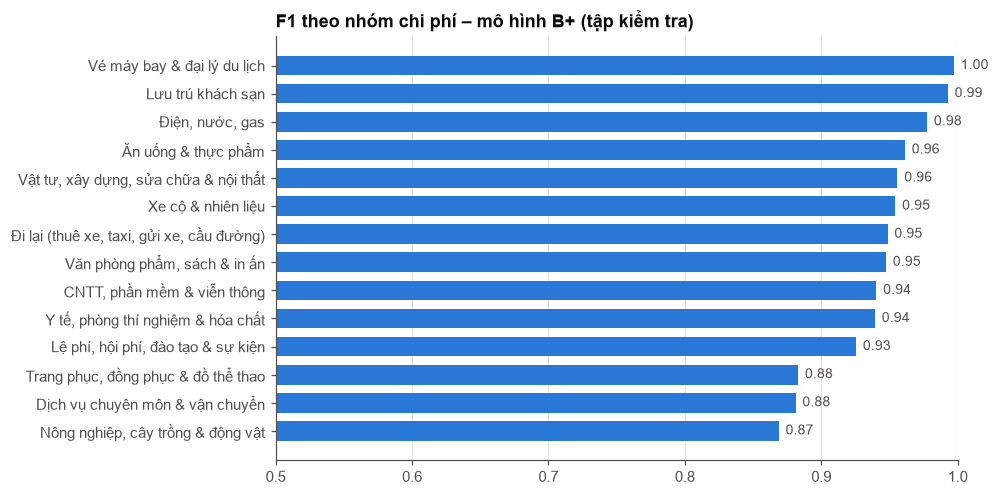

,precision,recall,f1-score,support
"Nông nghiệp, cây trồng & động vật",0.94,0.81,0.87,892
Dịch vụ chuyên môn & vận chuyển,0.90,0.86,0.88,"5,940"
"Trang phục, đồng phục & đồ thể thao",0.93,0.84,0.88,"1,267"
"Lệ phí, hội phí, đào tạo & sự kiện",0.91,0.95,0.93,"7,638"
"Y tế, phòng thí nghiệm & hóa chất",0.94,0.94,0.94,"4,736"
"CNTT, phần mềm & viễn thông",0.94,0.94,0.94,"7,473"
"Văn phòng phẩm, sách & in ấn",0.95,0.94,0.95,"3,857"
"Đi lại (thuê xe, taxi, gửi xe, cầu đường)",0.99,0.91,0.95,"1,285"
Xe cộ & nhiên liệu,0.96,0.95,0.95,"3,634"
"Vật tư, xây dựng, sửa chữa & nội thất",0.94,0.97,0.96,"15,018"


In [6]:
best = preds['B+. Văn bản + ngữ cảnh']
report = pd.DataFrame(classification_report(test.label, best, output_dict=True)).T
per_class = report.loc[list(GROUPS)[:14]].rename(index=GROUPS)[['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(per_class.index, per_class['f1-score'], color=BLUE, height=0.7)
ax.set_xlim(0.5, 1); ax.set_title('F1 theo nhóm chi phí – mô hình B+ (tập kiểm tra)')
ax.grid(axis='y', visible=False)
for i, v in enumerate(per_class['f1-score']):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9, color=INK2)
plt.show()
per_class.style.format({'precision': '{:.2f}', 'recall': '{:.2f}', 'f1-score': '{:.2f}', 'support': '{:,.0f}'})

In [7]:
cm = pd.crosstab(test.label.map(GROUPS), best.map(GROUPS))
cm = cm.mask(np.equal.outer(cm.index.to_numpy(), cm.columns.to_numpy()), 0)
pairs = cm.stack().sort_values(ascending=False).head(8)
pairs.index.names = ['Nhóm thật', 'Đoán nhầm thành']
pairs.rename('Số giao dịch').to_frame()

Số giao dịch
Nhóm thật                             Đoán nhầm thành                                    
Dịch vụ chuyên môn & vận chuyển       Lệ phí, hội phí, đào tạo & sự kiện              264
                                      Vật tư, xây dựng, sửa chữa & nội thất           202
                                      CNTT, phần mềm & viễn thông                     186
Lệ phí, hội phí, đào tạo & sự kiện    Dịch vụ chuyên môn & vận chuyển                 123
Y tế, phòng thí nghiệm & hóa chất     Vật tư, xây dựng, sửa chữa & nội thất           123
Vật tư, xây dựng, sửa chữa & nội thất Y tế, phòng thí nghiệm & hóa chất               119
CNTT, phần mềm & viễn thông           Vật tư, xây dựng, sửa chữa & nội thất           111
                                      Dịch vụ chuyên môn & vận chuyển                 110

**Nhận xét:** các nhóm có đặc trưng rõ (vé máy bay, lưu trú, điện nước) gần như không sai. Các nhầm lẫn chủ yếu nằm giữa những nhóm có ranh giới mờ về nghiệp vụ, ví dụ vật tư – sửa chữa với y tế – phòng thí nghiệm, hay dịch vụ với lệ phí. Nhiều trường hợp trong số này ngay cả kế toán cũng phải xem hóa đơn mới quyết định được.

## 5. Độ tin cậy và ngưỡng chuyển sang LLM

Theo bản phân tích nghiệp vụ: giao dịch mà mô hình **không chắc chắn** sẽ chuyển cho LLM. Bảng dưới đây cho thấy với mỗi ngưỡng xác suất thì bao nhiêu giao dịch mô hình tự xử lý, và độ chính xác ở hai phía ngưỡng.

In [8]:
m, cols = models['B+. Văn bản + ngữ cảnh']
proba = m.predict_proba(test[cols])
conf = proba.max(axis=1)
correct = (m.classes_[proba.argmax(axis=1)] == test.label.values)

rows = []
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    keep = conf >= t
    rows.append({'Ngưỡng': t, 'Mô hình tự xử lý': keep.mean(), 'Acc phần tự xử lý': correct[keep].mean(),
                 'Chuyển LLM': 1 - keep.mean(), 'Acc của mô hình ở phần chuyển LLM': correct[~keep].mean()})
pd.DataFrame(rows).set_index('Ngưỡng').style.format('{:.1%}')

,Mô hình tự xử lý,Acc phần tự xử lý,Chuyển LLM,Acc của mô hình ở phần chuyển LLM
Ngưỡng,,,,
0.500000,95.6%,97.3%,4.4%,44.2%
0.600000,93.4%,98.0%,6.6%,51.3%
0.700000,90.9%,98.7%,9.1%,58.2%
0.800000,87.5%,99.1%,12.5%,65.9%
0.900000,80.7%,99.6%,19.3%,75.5%


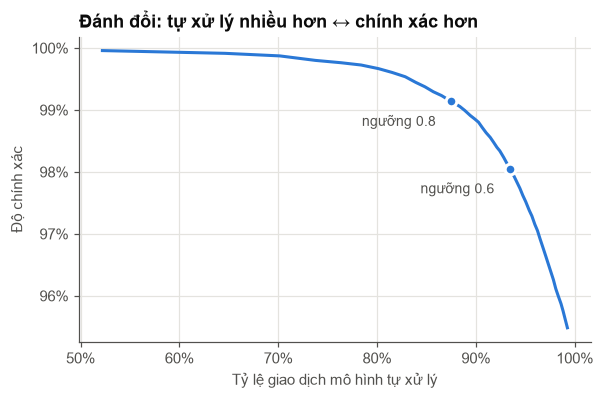

In [9]:
ts = np.linspace(0.3, 0.99, 50)
cov = [(conf >= t).mean() for t in ts]
acc = [correct[conf >= t].mean() for t in ts]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(cov, acc, color=BLUE, linewidth=2)
for t in [0.6, 0.8]:
    k = conf >= t
    ax.plot(k.mean(), correct[k].mean(), 'o', color=BLUE, markersize=7, markeredgecolor='white', markeredgewidth=2)
    ax.annotate(f'ngưỡng {t}', (k.mean(), correct[k].mean()), textcoords='offset points', xytext=(-10, -16), fontsize=9, color=INK2, ha='right')
ax.set_xlabel('Tỷ lệ giao dịch mô hình tự xử lý'); ax.set_ylabel('Độ chính xác')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Đánh đổi: tự xử lý nhiều hơn ↔ chính xác hơn')
plt.show()

**Nhận xét:** độ tin cậy của mô hình phản ánh khá đúng khả năng đoán đúng. Ở ngưỡng khoảng 0,8, mô hình tự xử lý phần lớn giao dịch với độ chính xác rất cao, còn phần nhỏ chuyển sang LLM là nơi mô hình hay sai nhất. Đây là cơ sở để chọn ngưỡng trong ứng dụng. Ngưỡng cuối cùng sẽ chọn trên tập kiểm định khi có kết quả của LLM.

## 6. Áp dụng cho giao dịch Amazon – vấn đề lệch miền dữ liệu

Áp dụng mô hình chỉ dùng mô tả cho các giao dịch Amazon có MCC "BOOK STORES" và mô tả cụ thể. Ở đây **chưa có nhãn đúng**, nên chỉ xem được phân bố và các ví dụ. Độ chính xác thật sẽ đo bằng tập gán nhãn tay (`data/labeling/amazon_eval_set.xlsx`).

In [10]:
amz = df[df.merchant.str.contains('AMAZON|AMZN', case=False) & (df.mcc_desc == 'BOOK STORES')
         & df.informative & (df.amount > 0)].copy()
for key, name in [('raw', 'C+. Mô tả + ngữ cảnh'), ('clean', 'C++. Mô tả đã làm sạch + ngữ cảnh')]:
    m, cols = models[name]
    pa = m.predict_proba(amz[cols])
    amz[f'pred_{key}'] = m.classes_[pa.argmax(axis=1)]
    amz[f'conf_{key}'] = pa.max(axis=1)
print(f'Giao dịch Amazon có mô tả cụ thể: {len(amz):,}')
pd.DataFrame({
    'C+ (văn bản gốc)': amz.pred_raw.map(GROUPS).value_counts(normalize=True),
    'C++ (đã làm sạch)': amz.pred_clean.map(GROUPS).value_counts(normalize=True),
}).fillna(0).sort_values('C++ (đã làm sạch)', ascending=False).style.format('{:.1%}')

Giao dịch Amazon có mô tả cụ thể: 74,795


,C+ (văn bản gốc),C++ (đã làm sạch)
"Vật tư, xây dựng, sửa chữa & nội thất",59.5%,44.1%
"Văn phòng phẩm, sách & in ấn",5.4%,22.5%
"CNTT, phần mềm & viễn thông",12.1%,12.7%
"Y tế, phòng thí nghiệm & hóa chất",16.6%,11.8%
Ăn uống & thực phẩm,0.8%,3.0%
Dịch vụ chuyên môn & vận chuyển,4.7%,2.3%
"Lệ phí, hội phí, đào tạo & sự kiện",0.5%,2.0%
"Trang phục, đồng phục & đồ thể thao",0.3%,0.8%
Xe cộ & nhiên liệu,0.1%,0.4%
"Nông nghiệp, cây trồng & động vật",0.0%,0.1%


**Vấn đề:** mô hình C+ dồn khoảng 60% giao dịch Amazon vào nhóm "Vật tư". Có hai nguyên nhân:
1. **Đuôi đơn vị tính:** 100% mô tả Amazon kết thúc bằng "PCE". Trong dữ liệu huấn luyện, các đuôi như "PCE", "EA" và dấu "|" (đơn nhiều món) chỉ xuất hiện ở một số nhà cung cấp cụ thể (FedEx, Grainger, nhà cung cấp phòng thí nghiệm…). Mô hình học theo các ký hiệu này thay vì học theo tên hàng.
2. **Lệch miền dữ liệu:** mô tả cụ thể trong tập huấn luyện chủ yếu đến từ nhà cung cấp công nghiệp. Đồ ăn hay văn phòng phẩm mua ở siêu thị thì hầu như chỉ ghi "GENERAL PURCHASE", nên mô hình ít khi thấy tên sản phẩm loại này.

In [11]:
inf_train = train[train.informative]
rows = []
for token in [' PCE', ' EA', '|']:
    hit = inf_train.item_desc.str.contains(token, regex=False)
    top = inf_train[hit].label.value_counts(normalize=True)
    rows.append({'Ký hiệu': token.strip(), 'Số dòng huấn luyện có ký hiệu': hit.sum(),
                 'Nhóm chiếm nhiều nhất': GROUPS[top.index[0]], 'Tỷ lệ': top.iloc[0],
                 'Tỷ lệ mô tả Amazon có ký hiệu': amz.item_desc.str.contains(token, regex=False).mean()})
pd.DataFrame(rows).style.format({'Tỷ lệ': '{:.0%}', 'Tỷ lệ mô tả Amazon có ký hiệu': '{:.0%}', 'Số dòng huấn luyện có ký hiệu': '{:,}'})

,Ký hiệu,Số dòng huấn luyện có ký hiệu,Nhóm chiếm nhiều nhất,Tỷ lệ,Tỷ lệ mô tả Amazon có ký hiệu
0,PCE,"3,881",Dịch vụ chuyên môn & vận chuyển,66%,100%
1,EA,"44,297","Vật tư, xây dựng, sửa chữa & nội thất",46%,0%
2,|,"24,478","Vật tư, xây dựng, sửa chữa & nội thất",47%,34%


**Cách xử lý:** làm sạch mô tả trước khi đưa vào mô hình (`src/features.py::clean_desc`): bỏ đuôi đơn vị tính của từng món và tách các món trong đơn. Ví dụ:

In [12]:
from src.features import clean_desc
ex = pd.Series(['EXPO Dry Erase Markers Lo PCE|EXPO Dry Erase White', 'Janitorial Supplies CS', 'BRAKE RESISTOR Z216 SERIE NMB|SHIPPING CHARGES NMB'])
pd.DataFrame({'Gốc': ex, 'Sau làm sạch': clean_desc(ex)})

,Gốc,Sau làm sạch
0,EXPO Dry Erase Markers Lo PCE|EXPO Dry Erase White,EXPO Dry Erase Markers Lo ; EXPO Dry Erase White
1,Janitorial Supplies CS,Janitorial Supplies
2,BRAKE RESISTOR Z216 SERIE NMB|SHIPPING CHARGES NMB,BRAKE RESISTOR Z216 SERIE ; SHIPPING CHARGES


In [13]:
probe_ids = [404876, 355053, 107192, 389037, 110241, 55595, 458264, 257240, 335839, 140517]
probe = amz.loc[[i for i in probe_ids if i in amz.index]]
probe[['item_desc', 'amount', 'pred_raw', 'pred_clean', 'conf_clean']]     .assign(pred_raw=lambda x: x.pred_raw.map(GROUPS), pred_clean=lambda x: x.pred_clean.map(GROUPS))     .rename(columns={'pred_raw': 'C+ (gốc)', 'pred_clean': 'C++ (làm sạch)', 'conf_clean': 'Độ tin cậy C++'})     .style.format({'amount': '${:,.2f}', 'Độ tin cậy C++': '{:.2f}'})

,item_desc,amount,C+ (gốc),C++ (làm sạch),Độ tin cậy C++
404876,Nissin Cup Noodles Ramen N PCE,$24.79,"Vật tư, xây dựng, sửa chữa & nội thất",Ăn uống & thực phẩm,0.66
355053,EXPO Dry Erase Markers Lo PCE|EXPO Dry Erase White,$43.89,"Vật tư, xây dựng, sửa chữa & nội thất","Văn phòng phẩm, sách & in ấn",0.79
107192,Good Strategy Bad Strategy PCE,$29.76,"Vật tư, xây dựng, sửa chữa & nội thất","Vật tư, xây dựng, sửa chữa & nội thất",0.37
389037,NES35170 - Liquid Coffee C PCE,$9.78,"Vật tư, xây dựng, sửa chữa & nội thất","CNTT, phần mềm & viễn thông",0.24
110241,Dixie PerfecTouch 12 oz. I PCE,$31.80,"Vật tư, xây dựng, sửa chữa & nội thất","Văn phòng phẩm, sách & in ấn",0.50
55595,Yuanhe Jumbo Large Playing PCE,$63.87,"Vật tư, xây dựng, sửa chữa & nội thất","Vật tư, xây dựng, sửa chữa & nội thất",0.58
458264,Karat FP-FT100G Food Tray PCE,$29.99,Dịch vụ chuyên môn & vận chuyển,Ăn uống & thực phẩm,0.53
257240,EUHOMY Countertop Ice Make PCE,$89.99,"Vật tư, xây dựng, sửa chữa & nội thất","Văn phòng phẩm, sách & in ấn",0.44
335839,Beats USB-C to USB-C Woven PCE|Apple Magic Trackpa,$377.37,"CNTT, phần mềm & viễn thông","CNTT, phần mềm & viễn thông",0.99
140517,Dial Complete Foaming Anti PCE,$22.50,"Y tế, phòng thí nghiệm & hóa chất","Y tế, phòng thí nghiệm & hóa chất",0.70


In [14]:
print(f"C+  – độ tin cậy ≥ 0,8: {(amz.conf_raw >= .8).mean():.1%}")
print(f"C++ – độ tin cậy ≥ 0,8: {(amz.conf_clean >= .8).mean():.1%} | < 0,5: {(amz.conf_clean < .5).mean():.1%}")

C+  – độ tin cậy ≥ 0,8: 26.8%
C++ – độ tin cậy ≥ 0,8: 20.4% | < 0,5: 38.8%


**Nhận xét:**
- Sau khi làm sạch, phân bố hợp lý hơn: nhóm "Vật tư" giảm mạnh, các nhóm văn phòng phẩm, ăn uống tăng lên. Nhiều ví dụ được sửa đúng (mì ăn liền → Ăn uống, bút viết bảng → Văn phòng phẩm). Đổi lại, độ chính xác trên dữ liệu thường (bảng mục 3) giảm nhẹ.
- Mô hình **vẫn còn sai rõ ràng** với nhiều sản phẩm (ví dụ sách, cà phê), và độ tin cậy trên Amazon thấp hơn hẳn so với giao dịch thông thường. Đây là giới hạn của học máy khi dữ liệu huấn luyện khác miền với dữ liệu cần dự đoán. Mô hình chỉ biết những gì có trong dữ liệu Oklahoma, trong khi một LLM có sẵn kiến thức chung về sản phẩm ("Nissin Cup Noodles" là đồ ăn).
- Như vậy, với Amazon, **mô hình xử lý phần có độ tin cậy cao, phần còn lại chuyển cho LLM**. Đây cũng là thực nghiệm so sánh "huấn luyện mô hình hay gọi LLM" đã đề ra trong bản phân tích nghiệp vụ, và sẽ được đo trên tập gán nhãn tay.

## 7. Lưu mô hình

In [15]:
out = ROOT / 'models'
out.mkdir(exist_ok=True)
joblib.dump({'model': models['B+. Văn bản + ngữ cảnh'][0], 'columns': models['B+. Văn bản + ngữ cảnh'][1]}, out / 'expense_clf_full.joblib')
joblib.dump({'model': models['C++. Mô tả đã làm sạch + ngữ cảnh'][0], 'columns': models['C++. Mô tả đã làm sạch + ngữ cảnh'][1]}, out / 'expense_clf_desc.joblib')
for f in sorted(out.glob('*.joblib')):
    print(f.name, f'{f.stat().st_size / 1e6:.1f} MB')

expense_clf_desc.joblib 16.2 MB
expense_clf_full.joblib 21.8 MB


## 8. Kết luận

1. **Mô hình B+** (văn bản + đơn vị + số tiền) là mô hình chính cho giao dịch thông thường: accuracy khoảng 95%, với cửa hàng mới trên 70%, vượt xa mốc tra cứu (khoảng 11%).
2. **Mô hình C++** (chỉ mô tả, đã làm sạch) dùng cho Amazon và cửa hàng bán đủ loại. Phải làm sạch đuôi đơn vị tính để tránh học nhầm. Dù vậy mô hình vẫn bị giới hạn bởi lệch miền dữ liệu, nên phần có độ tin cậy thấp cần chuyển cho LLM. Độ chính xác thật phải đo bằng tập gán nhãn tay.
3. **Độ tin cậy** của mô hình đủ tin cậy để làm ngưỡng chuyển sang LLM, đúng như thiết kế trong bản phân tích nghiệp vụ.
4. **Hạn chế:** nhãn suy từ MCC chứ không phải nhãn hạch toán thật; ranh giới giữa một số nhóm (vật tư – y tế, dịch vụ – lệ phí) mờ về nghiệp vụ.
5. **Bước tiếp theo:** gán nhãn tay tập Amazon → đo mô hình C++ → so sánh với LLM trên cùng tập (thực nghiệm "huấn luyện mô hình hay gọi LLM" trong bản phân tích).